# Análisis exploratorio (EDA) del conjunto de entrenaimento

10-09-2026
- Luis Pablo López Iracheta

**Objetivo:** conocer las características generales del dataset de entrenamiento (detección de objetos, formato YOLO): cantidad de imágenes, distribución de clases, número de objetos por imagen, tamaño y posición de las cajas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# pd.set_option("display.float_format", lambda v: f"{v:.4f}") # Tamaño para mostrar los números en pandas

In [2]:
# Rutas (este notebook vive en Analysis/, el dataset en data_1/)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
SPLIT = "train"
IMAGES_DIR = BASE_DIR / "data_1" / SPLIT / "images"
LABELS_DIR = BASE_DIR / "data_1" / SPLIT / "labels"

# Clases definidas en data_1/data.yaml
CLASSES = ['Bad Weld', 'Good Weld', 'Defect']

assert IMAGES_DIR.is_dir() and LABELS_DIR.is_dir(), "Error al buscar carpetas"
print("Imágenes:", IMAGES_DIR)
print("Etiquetas:", LABELS_DIR)

Imágenes: c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1\train\images
Etiquetas: c:\IBERO\A7Semestre\Integracion_de_aplicaciones\XYRON_VISION\data_1\train\labels


In [3]:
# Cargar todas las anotaciones YOLO a un DataFrame
# Formato por línea: <class_id> <x_center> <y_center> <width> <height>  (normalizado 0-1)
image_files = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() == ".jpg")

filas = []
img_meta = []
# Se recorre cada imagen y se leen sus anotaciones
for img_path in image_files:
    with Image.open(img_path) as im:
        W, H = im.size
    label_path = LABELS_DIR / (img_path.stem + ".txt")
    n_obj = 0
    if label_path.is_file():
        for linea in label_path.read_text().strip().splitlines():
            if not linea.strip():
                continue
            cid, xc, yc, bw, bh = linea.split()
            cid = int(float(cid))
            filas.append({
                "image": img_path.name,
                "class_id": cid,
                "class": CLASSES[cid] if cid < len(CLASSES) else f"id_{cid}",
                "x_center": float(xc), "y_center": float(yc),
                "w": float(bw), "h": float(bh),
            })
            n_obj += 1
    img_meta.append({
        "image": img_path.name, "width": W, "height": H,
        "size_kb": img_path.stat().st_size / 1024, "n_objetos": n_obj,
    })

df = pd.DataFrame(filas)
img_df = pd.DataFrame(img_meta)

# Columnas derivadas para las cajas
df["area"] = df["w"] * df["h"]                 # área relativa (fracción de la imagen)
df["aspect_ratio"] = df["w"] / df["h"]        # ancho / alto

print(f"{len(df)} cajas en {df['image'].nunique()} imágenes anotadas")
print(df.head())

3126 cajas en 834 imágenes anotadas
                                               image  class_id   class  \
0  0e538f39-1d30436c-c23_jpg.rf.05ff78024b481ae4f...         2  Defect   
1  0e538f39-1d30436c-c23_jpg.rf.26d4bf7a38b3bf419...         2  Defect   
2  0e538f39-1d30436c-c23_jpg.rf.3ce38b0e86b3cd83d...         2  Defect   
3  0e538f39-1d30436c-c23_jpg.rf.68d881523d9df5f75...         2  Defect   
4  0e538f39-1d30436c-c23_jpg.rf.77546dd3e656d80bb...         2  Defect   

   x_center  y_center         w         h      area  aspect_ratio  
0  0.525000  0.414844  0.178125  0.417969  0.074451      0.426168  
1  0.414844  0.525000  0.417969  0.178125  0.074451      2.346491  
2  0.585156  0.525000  0.417969  0.178125  0.074451      2.346491  
3  0.414844  0.475000  0.417969  0.178125  0.074451      2.346491  
4  0.585156  0.475000  0.417969  0.178125  0.074451      2.346491  


In [4]:
# Resumen general del dataset
n_images = len(image_files)
n_labels = sum(1 for p in image_files if (LABELS_DIR / (p.stem + '.txt')).is_file())
n_sin_obj = int((img_df["n_objetos"] == 0).sum())

print("Resumen del dataset:")
print(f"Imágenes totales: {n_images}")
print(f"Imágenes con archivo .txt   : {n_labels}")
print(f"Imágenes sin ningún objeto  : {n_sin_obj}")
print(f"Cajas (objetos) totales     : {len(df)}")
print(f"Promedio de objetos/imagen  : {len(df) / n_images:.2f}")
print()
print("Dimensiones de imagen (px):")
print(img_df[["width", "height"]].describe().loc[["min", "mean", "max"]])
print()
print("Peso de archivo (KB):")
print(img_df["size_kb"].describe()[["min", "mean", "50%", "max"]])

Resumen del dataset:
Imágenes totales: 834
Imágenes con archivo .txt   : 834
Imágenes sin ningún objeto  : 0
Cajas (objetos) totales     : 3126
Promedio de objetos/imagen  : 3.75

Dimensiones de imagen (px):
      width  height
min   640.0   640.0
mean  640.0   640.0
max   640.0   640.0

Peso de archivo (KB):
min      19.971680
mean     50.492232
50%      44.221191
max     134.874023
Name: size_kb, dtype: float64


           cajas  porcentaje
class                       
Bad Weld     732        23.4
Good Weld   1109        35.5
Defect      1285        41.1

Desbalance (max/min): 1.8x


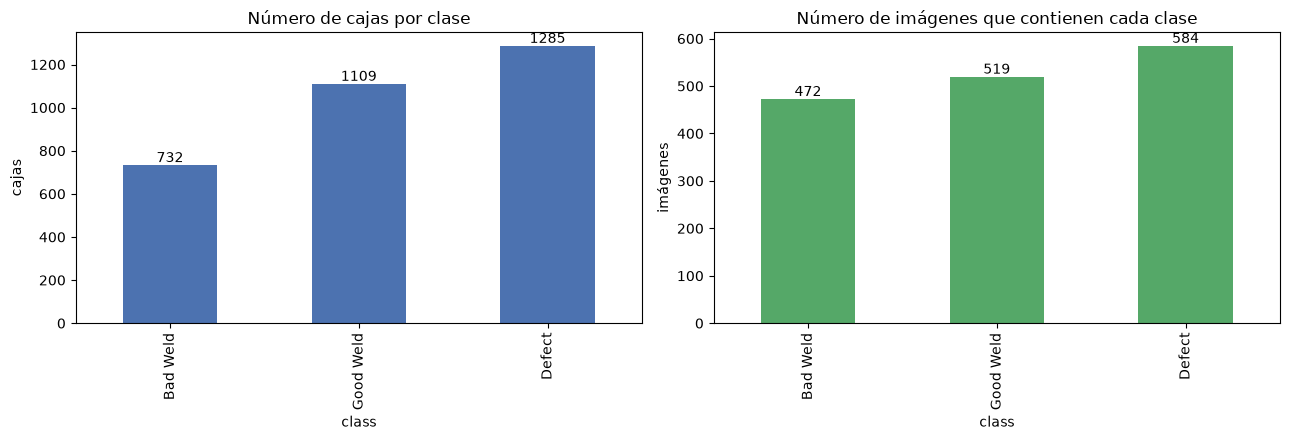

In [5]:
# Distribución de clases (número de cajas por clase)
conteo = df["class"].value_counts().reindex(CLASSES)
porc = (conteo / conteo.sum() * 100).round(1)
tabla = pd.DataFrame({"cajas": conteo, "porcentaje": porc})
print(tabla)
print(f"\nDesbalance (max/min): {conteo.max() / conteo.min():.1f}x")

# Imágenes en las que aparece cada clase
img_por_clase = df.groupby("class")["image"].nunique().reindex(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
conteo.plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Número de cajas por clase")
axes[0].set_ylabel("cajas")
for i, v in enumerate(conteo):
    axes[0].text(i, v, str(int(v)), ha="center", va="bottom")

img_por_clase.plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Número de imágenes que contienen cada clase")
axes[1].set_ylabel("imágenes")
for i, v in enumerate(img_por_clase):
    axes[1].text(i, v, str(int(v)), ha="center", va="bottom")

plt.tight_layout()
plt.show()

min      1.000000
mean     3.748201
50%      3.000000
max     25.000000
Name: n_objetos, dtype: float64

Frecuencia:
n_objetos
1     219
2     166
3     113
4      81
5      77
6      57
7      36
8      22
9      19
10     10
11      7
12      5
13      5
14      3
15      5
16      3
18      2
19      2
20      1
25      1
Name: count, dtype: int64


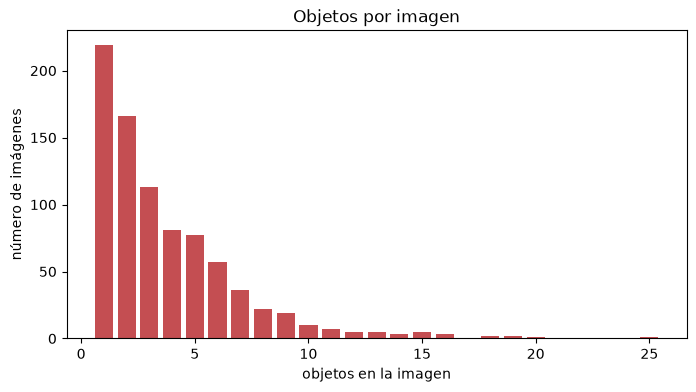

In [6]:
# Distribución del número de objetos por imagen
print(img_df["n_objetos"].describe()[["min", "mean", "50%", "max"]])
print("\nFrecuencia:")
print(img_df["n_objetos"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
vc = img_df["n_objetos"].value_counts().sort_index()
plt.bar(vc.index, vc.values, color="#C44E52")
plt.xlabel("objetos en la imagen")
plt.ylabel("número de imágenes")
plt.title("Objetos por imagen")
plt.show()

            w         h      area  aspect_ratio
min  0.010937  0.017969  0.000308      0.026549
25%  0.067187  0.069531  0.009498      0.252098
50%  0.134766  0.131250  0.018787      1.170090
75%  0.250000  0.303320  0.042500      3.134550
max  0.998437  0.998437  0.928340     21.260000


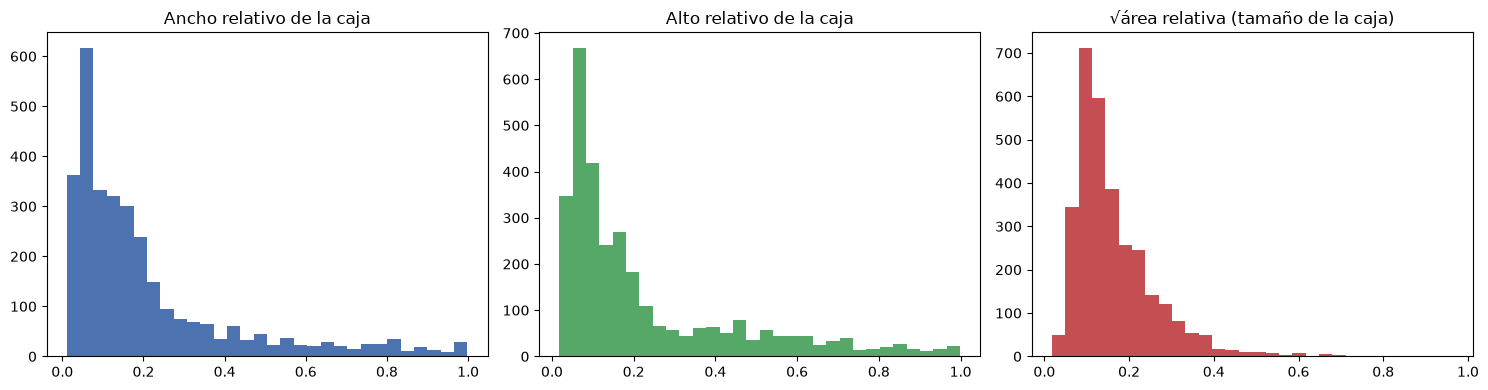

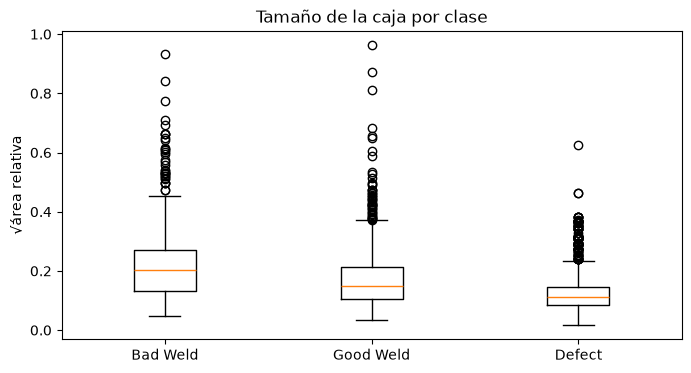

In [7]:
# Tamaño de las cajas (valores relativos a la imagen)
print(df[["w", "h", "area", "aspect_ratio"]].describe().loc[["min", "25%", "50%", "75%", "max"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["w"], bins=30, color="#4C72B0"); axes[0].set_title("Ancho relativo de la caja")
axes[1].hist(df["h"], bins=30, color="#55A868"); axes[1].set_title("Alto relativo de la caja")
axes[2].hist(np.sqrt(df["area"]), bins=30, color="#C44E52"); axes[2].set_title("√área relativa (tamaño de la caja)")
plt.tight_layout()
plt.show()

# Tamaño de caja por clase
plt.figure(figsize=(8, 4))
datos = [np.sqrt(df.loc[df["class"] == c, "area"]) for c in CLASSES]
plt.boxplot(datos, tick_labels=CLASSES)
plt.ylabel("√área relativa")
plt.title("Tamaño de la caja por clase")
plt.show()

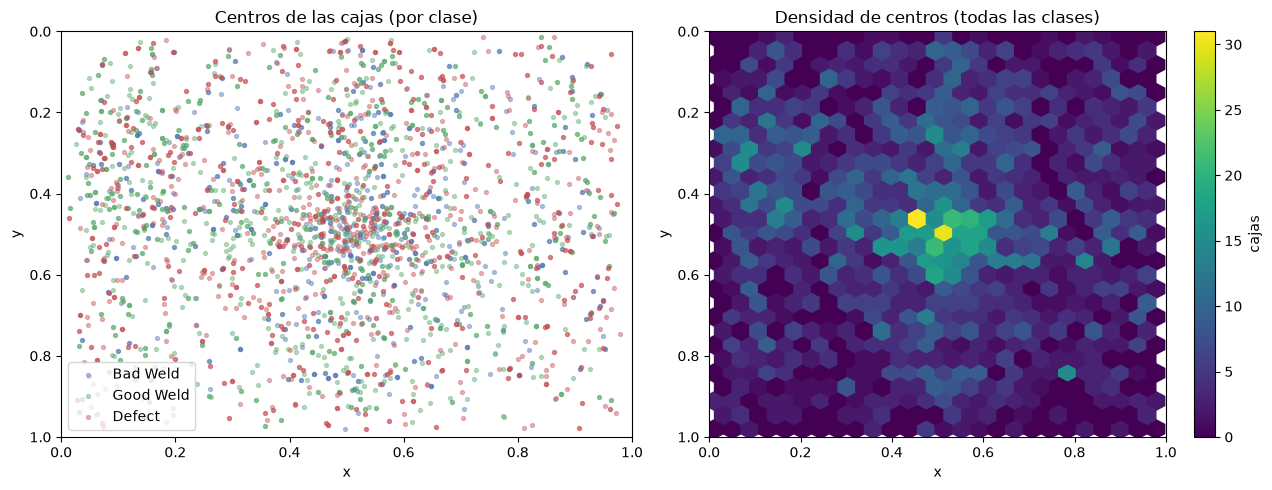

In [8]:
# Posición de los centros de las cajas dentro de la imagen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores = {"Bad Weld": "#4C72B0", "Good Weld": "#55A868", "Defect": "#C44E52"}
for c in CLASSES:
    sub = df[df["class"] == c]
    axes[0].scatter(sub["x_center"], sub["y_center"], s=8, alpha=0.4, label=c, color=colores.get(c))
axes[0].set_xlim(0, 1); axes[0].set_ylim(1, 0)
axes[0].set_title("Centros de las cajas (por clase)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].legend()

hb = axes[1].hexbin(df["x_center"], df["y_center"], gridsize=25, cmap="viridis")
axes[1].set_xlim(0, 1); axes[1].set_ylim(1, 0)
axes[1].set_title("Densidad de centros (todas las clases)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
fig.colorbar(hb, ax=axes[1], label="cajas")

plt.tight_layout()
plt.show()

In [9]:
# ¿Qué clases aparecen juntas en la misma imagen?
presencia = df.groupby("image")["class"].apply(set)
combo = presencia.apply(lambda s: " + ".join(sorted(s))).value_counts()
print("Combinaciones de clases por imagen:")
print(combo)

# Matriz de co-ocurrencia
co = pd.DataFrame(0, index=CLASSES, columns=CLASSES)
for s in presencia:
    for a in s:
        for b in s:
            co.loc[a, b] += 1
print("\nMatriz de co-ocurrencia (imágenes):")
print(co)

Combinaciones de clases por imagen:
class
Bad Weld + Defect + Good Weld    264
Good Weld                        209
Bad Weld + Defect                167
Defect                           121
Defect + Good Weld                32
Bad Weld                          27
Bad Weld + Good Weld              14
Name: count, dtype: int64

Matriz de co-ocurrencia (imágenes):
           Bad Weld  Good Weld  Defect
Bad Weld        472        278     431
Good Weld       278        519     296
Defect          431        296     584


## Observaciones (resultados del split `train`)

- **Tamaño del split:** 834 imágenes, todas anotadas (0 imágenes de fondo), 3 126 cajas en total → **3.75 objetos por imagen** en promedio.
- **Imágenes:** todas de **640×640 px**, RGB, entre ~20 y ~135 KB.
- **Balance de clases:** `Defect` 41.1 % (1 285), `Good Weld` 35.5 % (1 109), `Bad Weld` 23.4 % (732). Desbalance moderado **1.8×** (max/min) — manejable, pero conviene vigilar el recall de `Bad Weld`.
- **Objetos por imagen:** muy variable (de 1 a 25). 219 imágenes tienen 1 solo objeto y la mayoría entre 2 y 6 → es un problema de **detección multiobjeto real**, no clasificación.
- **Tamaño de cajas:** mediana de √área ≈ 0.14 (caja ~14 % del lado de la imagen). Hay cola de cajas muy pequeñas (√área < 0.05) que serán las más difíciles de detectar.
- **Relación de aspecto:** muy dispersa (mediana ~1.17, rango 0.03–21). Coexisten defectos alargados horizontales y verticales → un modelo con anchors/relaciones de aspecto flexibles ayuda.
- **Co-ocurrencia:** en 264 imágenes aparecen las 3 clases juntas; `Bad Weld` casi nunca aparece sin `Defect` (472 vs 431 co-ocurrencias).
- **Posición:** revisar el hexbin — los centros tienden a concentrarse en la franja central de la imagen (posible sesgo posicional).

### Implicaciones para el modelado
1. Estratificar el split train/val por clase para conservar las proporciones.
2. Considerar aumento de datos o ponderación de pérdida para `Bad Weld`.
3. Usar resolución de entrada ≥ 640 para no perder las cajas pequeñas.